# Linear Regression with scikit-learn

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>Linear regression in practice</b> almost always means scikit-learn's <code>LinearRegression</code>. In real projects you reach for sklearn rather than implementing the math yourself — it handles all the computation and is the standard tool across the industry. The model is the same one you have seen before, extended to multiple features — each feature gets its own weight:

<code>y_pred = w₁·x₁ + w₂·x₂ + ... + wₙ·xₙ + b</code>

In compact matrix notation (which you may have seen in the NumPy tutorial): <code>y_pred = X @ w + b</code>, where <code>X</code> is the matrix of all feature values, <code>w</code> is the vector of weights, and <code>@</code> is Python's matrix multiplication operator. scikit-learn solves for all weights and the bias in one step using a closed-form formula — no iterating required.

<b>The core training workflow</b> has four parts: (1) split the data into a training set and a held-out test set, (2) <code>fit</code> the model on the training set only, (3) <code>predict</code> on both sets, (4) compare metrics — MAE, RMSE, R<sup>2</sup> — to see how well the model generalises to data it hasn't seen.

In this notebook you will run that workflow on a real multi-feature dataset (Auto MPG: predict fuel economy from car specs), interpret what the model learned, and meet a few common mistakes that quietly ruin results.

</div>

---
## Step 1: Load and Look at the Data

The Auto MPG dataset records fuel economy and specifications for 398 cars from 1970–1982. We will predict `mpg` (miles per gallon) from physical specs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

df = pd.read_csv('auto_mpg.csv')
print(f"shape: {df.shape}")
df.head()

shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
# Quick checks: dtypes and missing values
print(df.dtypes)
print(f"\nmissing values per column:\n{df.isna().sum()}")

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


A few notes before we model:

- `horsepower` has 6 missing values — we will drop those rows for now.
- `origin` is categorical (USA / Europe / Japan) and `name` is the car's model name. Both need special handling that we will cover later in the course; for this tutorial we use **only the numerical features**.

In [3]:
# Drop only the rows with missing horsepower, then keep only numerical columns
df = df.dropna(subset=['horsepower'])
df = df.drop(columns=['origin', 'name'])

print(f"shape after cleaning: {df.shape}")
df.head()

shape after cleaning: (392, 7)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


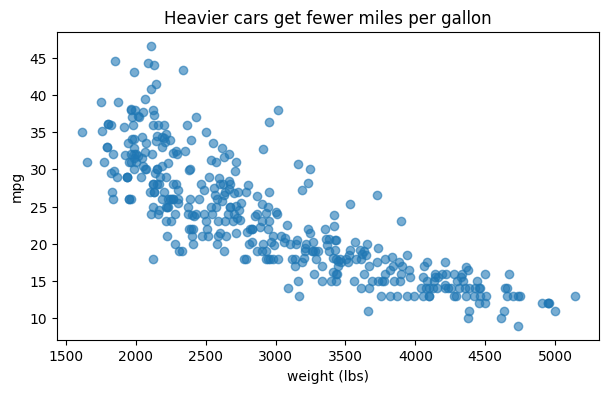

In [4]:
# One quick EDA plot — relationship between weight and mpg
plt.figure(figsize=(7, 4))
plt.scatter(df['weight'], df['mpg'], alpha=0.6)
plt.xlabel('weight (lbs)')
plt.ylabel('mpg')
plt.title('Heavier cars get fewer miles per gallon')
plt.show()

Clear negative relationship: weight predicts mpg fairly well on its own. A linear regression on **all** the numerical features will combine multiple signals into a single prediction.

---
## Step 2: Train / Test Split

Before training anything, we hold out part of the data as a **test set** — rows the model will never see during training. The test set is the only honest measure of how well the model will perform on new data.

Standard convention for small datasets: 80% train, 20% test.

> **Note:** A two-way split is sufficient here because in this notebook we make no decisions based on performance — we fit one model with a fixed set of features and evaluate it. A validation set becomes necessary as soon as you use metrics to make any decision during development: comparing preprocessing strategies, selecting features, tuning regularization strength, or choosing between models. That workflow — train / validation / test — is covered later in the course.

In [5]:
# Features (X) and target (y)
y = df['mpg']
X = df.drop(columns=['mpg'])

# 80/20 split — random_state fixes the split so results are reproducible
# shuffle=True by default — important here since the dataset is ordered by year
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}    X_test: {X_test.shape}")

X_train: (313, 6)    X_test: (79, 6)


---
## Step 3: Fit the Model

scikit-learn's API is consistent across every model: create an instance, call `.fit(X, y)` to train, call `.predict(X)` to use it.

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print("Model trained. Predictions ready.")

Model trained. Predictions ready.


---
## Step 4: Evaluate

Three metrics summarise how good the predictions are — each answers a slightly different question:

- **MAE** (Mean Absolute Error) — average absolute error, in the target's units. "On average our prediction is off by X mpg."
- **RMSE** (Root Mean Squared Error) — same units as the target, but penalises large errors disproportionately because errors are squared before averaging.
- **R²** (coefficient of determination) — fraction of the target's variance the model explains, compared with always predicting the mean. `1.0` is perfect; `0.0` is no better than predicting the mean; negative means the model is worse than that baseline.

Always evaluate on the **test set** — but compute both so you can compare and spot overfitting.

In [11]:
def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<10s}  MAE={mae:.2f}   RMSE={rmse:.2f}   R²={r2:.3f}")

report("train:", y_train, y_train_pred)
report("test:",  y_test,  y_test_pred)

train:      MAE=2.67   RMSE=3.46   R²=0.811
test:       MAE=2.50   RMSE=3.24   R²=0.794


Read the numbers honestly:

- **MAE/RMSE on the test set** is the model's typical error in mpg. The closer to 0, the better.
- The **gap between train and test** matters. A model that scores much better on train than on test is **overfitting** — it has memorised the training rows in ways that don't generalise. A small gap means the model is honest about what it learned.
- You may notice that MAE and RMSE are slightly *better* on the test set than on training. This is normal with small datasets — the 79 rows that ended up in the test set happened to be slightly easier to predict than average. It is sampling variation in the split, not a sign of anything wrong.

---
## Step 5: What Did the Model Learn?

A trained `LinearRegression` exposes the parameters it learned as `model.intercept_` and `model.coef_` (one coefficient per feature, in the same order as the feature columns). These correspond directly to what you optimised by hand in the previous notebook: `intercept_` is `b` (the bias) and `coef_` is the learned weights vector `w`, one value per feature.

In [12]:
print(f"intercept: {model.intercept_:+.3f}")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat:<14s} {coef:+.4f}")

intercept: -15.058
  cylinders      -0.1162
  displacement   +0.0010
  horsepower     -0.0023
  weight         -0.0066
  acceleration   +0.0617
  model_year     +0.7606


Each coefficient says: holding all other features fixed, a one-unit increase in this feature changes the predicted `mpg` by this many. Look at the printed `model_year` coefficient — it is **positive**, meaning newer cars get more mpg per year, which lines up with what real-world fuel-economy progress looked like in that era. The `weight` coefficient is **negative** — heavier cars get worse mpg, as expected.

Some coefficients may look counterintuitive — for example, `displacement` is slightly positive even though larger engines typically consume more fuel. This happens because features like `cylinders`, `displacement`, `horsepower`, and `weight` are all highly correlated with each other. When correlated features are present, individual coefficients can be pulled in unexpected directions — each one represents the effect of that feature *after accounting for all the others*. This is called **multicollinearity** and is one reason raw coefficients from multi-feature linear regression require careful interpretation.

> **Note:** Coefficient *magnitudes* are not directly comparable across features because the features are on different scales (`weight` is in thousands, `cylinders` is single digits). To rank features by importance you would first need to scale them — a technique we cover later in the course.

---
## Step 6: Predictions vs Actuals

In the previous notebook you could plot the fitted line directly on the data — one feature, two axes, draw the line. With six features the model fits a hyperplane in seven-dimensional space; there is no single axis to plot it against. The most useful diagnostic plot for a multi-feature regression model is predictions vs actuals: actual values on the x-axis, predicted values on the y-axis. Perfect predictions land on the diagonal; the spread around the diagonal shows the model's typical error.

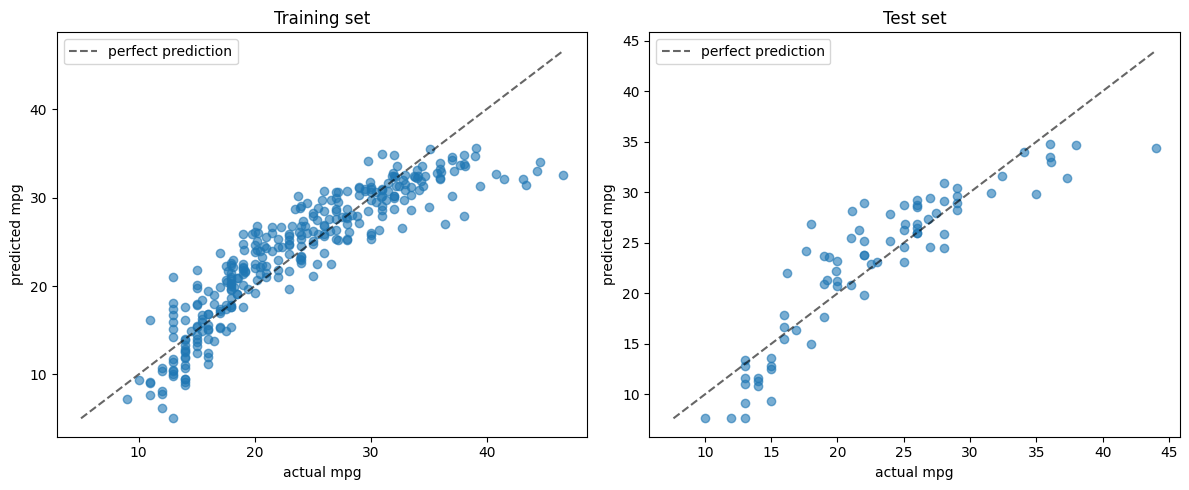

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (ax1, y_train, y_train_pred, 'Training set'),
    (ax2, y_test,  y_test_pred,  'Test set'),
]:
    ax.scatter(y_true, y_pred, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.6, label='perfect prediction')
    ax.set_xlabel('actual mpg')
    ax.set_ylabel('predicted mpg')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

Two things to read from this plot:

1. **Are points clustered near the diagonal?** The tighter the cloud around the dashed line, the smaller the typical error.
2. **Is there systematic bias?** If points consistently fall above or below the diagonal at one end of the range, the model has a structural problem — the true relationship isn't well captured by a straight line. Slight curvature at the extremes is common for Auto MPG and is a hint that the underlying relationship is mildly non-linear.

---
## Step 7: Common Mistakes to Avoid

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #f59e0b;color:#e2e8f0">

<b>1. Fitting on the test set (or on all the data).</b> Only call <code>.fit()</code> on training data. If you fit on the test set, your evaluation lies — you have already shown the model the answers.

<b>2. Forgetting <code>random_state</code>.</b> Without it, every run gets a different train/test split, so results are not comparable. Pick any integer and stick with it.

<b>3. Computing summary statistics on all data before splitting.</b> A common subtle bug: you compute the mean (or another statistic) from the full dataset and use it to transform features, then split. The training-set statistics are now contaminated by information from the test set. The correct order is split first, compute statistics on train only, apply to both.

<b>4. Reporting only training metrics.</b> A model can score perfectly on the data it trained on while failing on new data. Always report metrics on a held-out test set — that is the number that says how well the model will work on real future inputs.

</div>

---
## What You Should Be Able to Do Now

- Load a real dataset, identify which columns are numeric vs. categorical, and drop rows with missing values
- Split a dataset into training and test sets with `train_test_split` and a fixed `random_state`
- Fit a multi-feature linear regression with scikit-learn's `LinearRegression.fit`
- Predict on both sets and compute MAE, RMSE, and R² for each
- Read the gap between train and test metrics as a signal of how well the model generalises
- Inspect `model.coef_` and `model.intercept_` and interpret a coefficient in plain words
- Plot predictions vs actuals and read the result for systematic bias
- Recognise four common pitfalls that silently break regression workflows